In [1]:
import numpy as np
import pandas as pd 
import seaborn as sn
import matplotlib.pyplot as plt 
%matplotlib inline 

### Exercise 1: Load & Explore

In [2]:
df = pd.read_csv('auto_mpg_synthetic_dataset.csv')
df.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,25.6,4,240.8,144,2832,18.2,72,1,Car_001
1,34.4,8,411.6,140,2344,15.9,79,1,Car_002
2,12.9,6,392.2,210,4301,14.5,76,3,Car_003
3,19.9,5,322.4,170,3244,16.9,76,1,Car_004
4,39.9,4,253.9,79,1500,17.4,70,1,Car_005


In [3]:
df.shape

(300, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           300 non-null    float64
 1   cylinders     300 non-null    int64  
 2   displacement  300 non-null    float64
 3   horsepower    300 non-null    int64  
 4   weight        300 non-null    int64  
 5   acceleration  300 non-null    float64
 6   model_year    300 non-null    int64  
 7   origin        300 non-null    int64  
 8   car_name      300 non-null    str    
dtypes: float64(3), int64(5), str(1)
memory usage: 21.2 KB


In [5]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.0000,300.000000
mean,27.211000,5.196667,316.861333,153.580000,2796.476667,15.067667,76.0500,1.836667
std,7.564451,1.494020,73.708896,32.989969,678.251591,2.039490,3.5782,0.867466
min,8.000000,3.000000,158.100000,79.000000,1500.000000,9.800000,70.0000,1.000000
25%,21.500000,4.000000,258.975000,129.750000,2291.750000,13.600000,73.0000,1.000000
50%,27.850000,4.000000,295.750000,153.500000,2789.000000,15.100000,76.0000,2.000000
75%,32.425000,6.000000,362.350000,175.000000,3244.750000,16.400000,79.0000,3.000000
max,46.600000,8.000000,500.000000,239.000000,4955.000000,20.200000,82.0000,3.000000


1. the datasets is compiled with 10 columns by 300 rows
2. the column target is mpg
3. the car_name contains a text datatype

### Exercise 2: Missing values

In [7]:
df.isnull().sum().sum()

np.int64(0)

1. no column contains missing values.
2. handling missing value is a prerequsite as ML models wont process your data with an Nan value 

### Exercise 3: EDA

#### MPG Distributions

[Text(0.5, 1.0, 'Distribution of MPG'), Text(0.5, 0, 'Miles Per Gallon')]

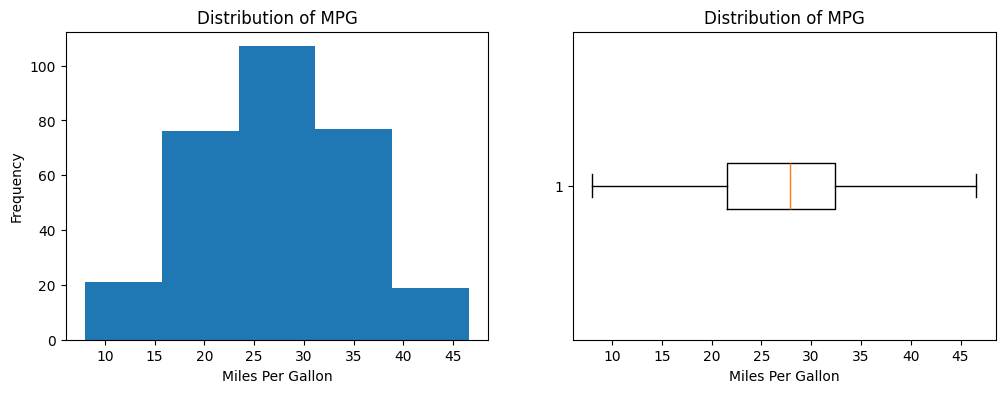

In [22]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,4))

ax1.hist(df['mpg'], 5)
ax1.set(title='Distribution of MPG', xlabel='Miles Per Gallon', ylabel='Frequency')

ax2.boxplot(df['mpg'], vert=False)
ax2.set(title='Distribution of MPG', xlabel='Miles Per Gallon')

#### Coorelation Visuals

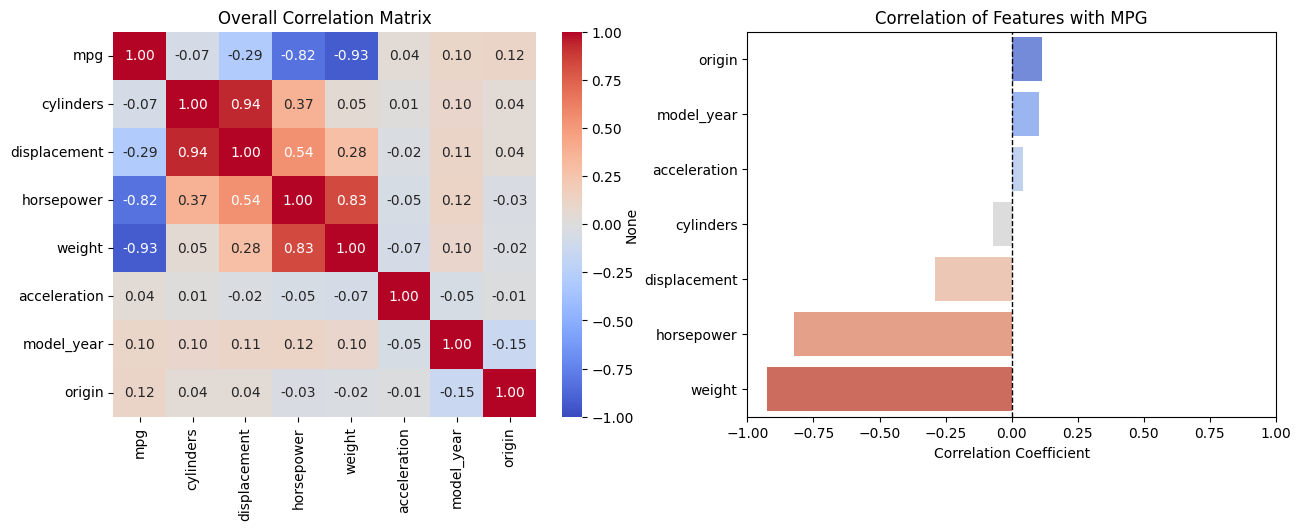

In [39]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 5))

numeric_df = df.select_dtypes(include='number').corr()
mpg_corr = numeric_df['mpg'].drop('mpg').sort_values(ascending=False)

sn.heatmap(
    numeric_df, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    vmin=-1, vmax=1, 
    ax=ax1
).set(title='Overall Correlation Matrix')

sn.barplot(
    x=mpg_corr.values, 
    y=mpg_corr.index, 
    hue=mpg_corr.index,
    palette='coolwarm', 
    ax=ax2
)
ax2.axvline(0, color='black', linestyle='--', linewidth=1)
ax2.set(title='Correlation of Features with MPG', xlabel='Correlation Coefficient', xlim=(-1, 1));

#### Scatter plots

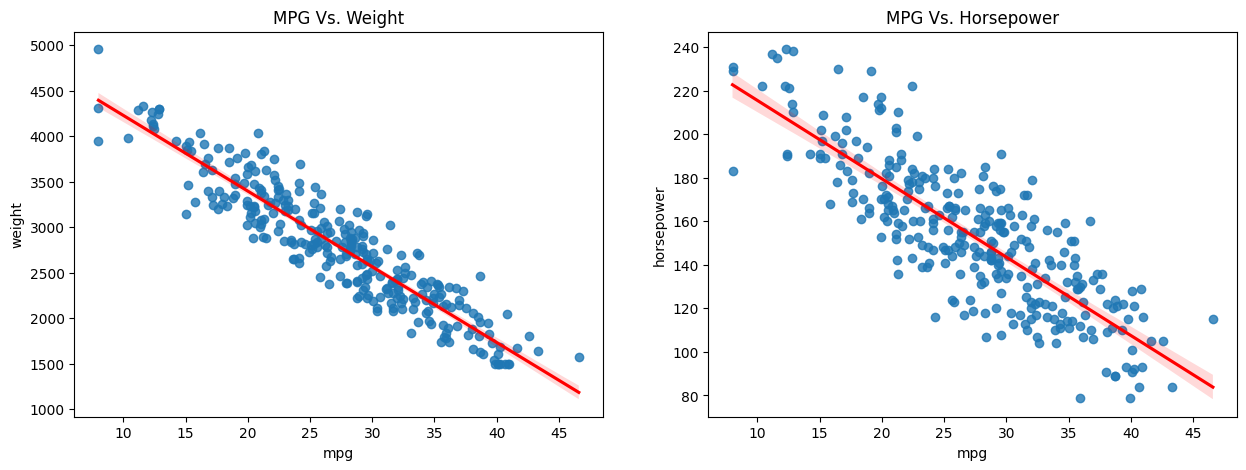

In [53]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 5))

sn.regplot(
    df,
    x='mpg',
    line_kws={'color':'red'},
    y='weight',
    ax=ax1
).set(title='MPG Vs. Weight')

sn.regplot(
    df,
    x='mpg',
    line_kws={'color':'red'},
    y='horsepower',
    ax=ax2
).set(title='MPG Vs. Horsepower');

#### MPG vs. Weight
    Relationship: Negative.The red trend line is sloping down 
    Strength: Strong. The points form a relatively tight, distinct downward trend.
    Outliers: maybe the single value up in the left.
    
#### MPG vs. Horsepower
    Relationship: Negative.The red trend line is sloping down 
    Strength: Strong. The points form a relatively tight, distinct downward trend.
    Outliers: maybe the single value at 180Hp

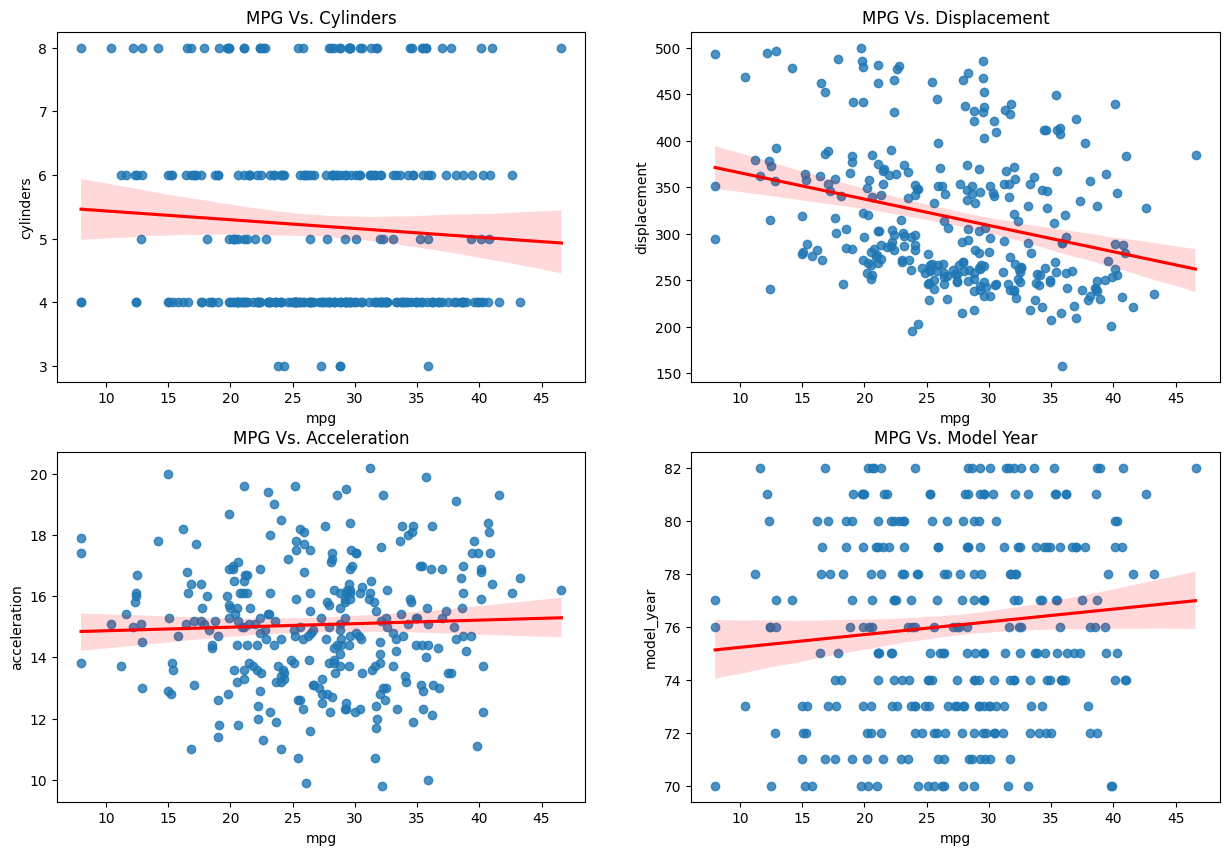

In [52]:
fig, ((ax3, ax4),(ax5,ax6)) = plt.subplots( nrows=2, ncols=2, figsize=(15, 10))

sn.regplot(
    df,
    x='mpg',
    line_kws={'color':'red'},
    y='cylinders',
    ax=ax3
).set(title='MPG Vs. Cylinders')

sn.regplot(
    df,
    x='mpg',
    line_kws={'color':'red'},
    y='displacement',
    ax=ax4
).set(title='MPG Vs. Displacement')

sn.regplot(
    df,
    x='mpg',
    line_kws={'color':'red'},
    y='acceleration',
    ax=ax5
).set(title='MPG Vs. Acceleration')

sn.regplot(
    df,
    x='mpg',
    line_kws={'color':'red'},
    y='model_year',
    ax=ax6
).set(title='MPG Vs. Model Year');

#### MPG vs. Cylinders
    Relationship: Negative.The red trend line is sloping down 
    Strength: Moderate. The data is grouped into distinct horizontal bands.
    Outliers: kinda. Unexpected points for 8-cylinder vehicles stretches.

#### MPG vs. Displacement
    Relationship: Negative.The red trend line is sloping down 
    Strength: Strong. The points form a relatively tight, distinct downward trend
    Outliers: kinda. isolated value at the right side which is separated from the main downward curve.
    
#### MPG vs. Acceleration
    Relationship: positive.The red trend line is sloping slightly up 
    Strength: Moderate. The data is grouped into distinct horizontal bands.
    Outliers: Yes. A few points sit far outside the central cloud

#### MPG vs. model_year
    Relationship: Positive.The red trend line is sloping up 
    Strength: Moderate. The data is grouped into distinct horizontal bands like cylinder.